In [2]:
import pandas as pd

master = pd.read_csv("data/processed/master_dataset.csv")

/var/folders/rl/n4sfdmss5mx9z6sw2mmr66900000gn/T/ipykernel_88077/3395227064.py:3: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv("data/processed/master_dataset.csv")


In [3]:
master.head()


,order_item_id,order_item_name,order_item_type,order_id,product_id,quantity,line_total,subtotal,tax,variation_id,...,max_price,onsale,stock_quantity,stock_status,rating_count,average_rating,total_sales_y,tax_status,tax_class,product_name
0,1,Finlay Xs Backpack,line_item,216,77.0,1.0,72.0,72.0,0.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,The Washable Silk Henley Tank,line_item,217,74.0,1.0,90.0,90.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,Black cotton dress 3 - M,line_item,2199,1328.0,1.0,1400.0,1400.0,0.0,1332.0,...,1400.0,0.0,NaN,instock,1.0,5.0,1009.0,taxable,NaN,Black cotton dress 3
3,7,Baby pink 2 tier cotton dress - XXS,line_item,2642,2381.0,1.0,1600.0,1600.0,0.0,2382.0,...,1550.0,0.0,NaN,instock,1.0,5.0,198.0,taxable,NaN,Baby pink 2 tier cotton dress
4,9,Black cotton dress 3 - M,line_item,2643,1328.0,1.0,1450.0,1450.0,0.0,1332.0,...,1400.0,0.0,NaN,instock,1.0,5.0,1009.0,taxable,NaN,Black cotton dress 3


In [4]:
print(f"Total Revenue: ₹{master['line_total'].sum():,.2f}")

Total Revenue: ₹44,831,205.20


In [6]:
print("Rows :", master.shape[0])
print("Columns :", master.shape[1])

master.info()

Rows : 26554
Columns : 48
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26554 entries, 0 to 26553
Data columns (total 48 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_item_id       26554 non-null  int64  
 1   order_item_name     26554 non-null  object 
 2   order_item_type     26554 non-null  object 
 3   order_id            26554 non-null  int64  
 4   product_id          26554 non-null  float64
 5   quantity            26554 non-null  float64
 6   line_total          26554 non-null  float64
 7   subtotal            26554 non-null  float64
 8   tax                 26554 non-null  float64
 9   variation_id        26554 non-null  float64
 10  parent_id           26516 non-null  float64
 11  date_created        26516 non-null  object 
 12  date_created_gmt    26516 non-null  object 
 13  num_items_sold      26516 non-null  float64
 14  total_sales_x       26516 non-null  float64
 15  tax_total           26516 n

In [7]:
missing = master.isnull().sum().sort_values(ascending=False)

missing[missing>0]

tax_class             26554
sku                   26552
stock_quantity        21169
date_completed         4179
product_name           3811
date_paid              3532
date_registered         937
user_id                 937
username                937
state                   115
postcode                 84
city                     74
country                  71
date_last_active         71
first_name               58
last_name                58
email                    58
total_sales_x            38
shipping_total           38
net_total                38
returning_customer       38
status                   38
customer_id              38
num_items_sold           38
date_created             38
tax_total                38
date_created_gmt         38
parent_id                38
stock_status              2
downloadable              2
virtual                   2
min_price                 2
max_price                 2
average_rating            2
rating_count              2
total_sales_y       

In [8]:
master.describe()

,order_item_id,order_id,product_id,quantity,line_total,subtotal,tax,variation_id,parent_id,num_items_sold,...,virtual,downloadable,min_price,max_price,onsale,stock_quantity,rating_count,average_rating,total_sales_y,tax_class
count,26554.000000,26554.000000,26554.000000,26554.000000,26554.000000,26554.000000,26554.0,26554.000000,26516.0,26516.000000,...,26552.0,26552.000000,26552.000000,26552.000000,26552.000000,5385.000000,26552.000000,26552.000000,26552.000000,0.0
mean,36966.750772,22800.220946,13907.524102,1.001770,1688.303276,1714.102809,0.0,13958.661030,0.0,2.470546,...,0.0,0.000075,1372.926484,1514.000603,0.000226,0.641597,1.098863,1.452009,341.525648,NaN
std,21973.651631,12610.942014,12333.631387,0.047105,396.740402,396.352016,0.0,12318.266158,0.0,2.364168,...,0.0,0.008679,601.407389,595.257240,0.015031,1.679805,2.470049,2.215105,532.421217,NaN
min,1.000000,216.000000,74.000000,1.000000,0.000000,4.000000,0.0,0.000000,0.0,1.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,NaN
25%,16719.250000,10658.000000,2391.000000,1.000000,1500.000000,1520.000000,0.0,2397.000000,0.0,1.000000,...,0.0,0.000000,1200.000000,1400.000000,0.000000,0.000000,0.000000,0.000000,27.000000,NaN
50%,38846.500000,23867.500000,10175.000000,1.000000,1600.000000,1600.000000,0.0,10569.000000,0.0,2.000000,...,0.0,0.000000,1350.000000,1600.000000,0.000000,0.000000,0.000000,0.000000,76.000000,NaN
75%,57224.500000,34485.250000,22725.000000,1.000000,1795.000000,1800.000000,0.0,22735.000000,0.0,3.000000,...,0.0,0.000000,1650.000000,1650.000000,0.000000,0.000000,1.000000,4.250000,320.000000,NaN
max,70812.000000,42672.000000,42452.000000,5.000000,7600.000000,7600.000000,0.0,42463.000000,0.0,19.000000,...,0.0,1.000000,7500.000000,7600.000000,1.000000,14.000000,9.000000,5.000000,1747.000000,NaN


In [9]:
total_revenue = master['line_total'].sum()

print(f"Total Revenue : ₹{total_revenue:,.2f}")

Total Revenue : ₹44,831,205.20


In [10]:
master['order_id'].nunique()

17444

In [11]:
master['customer_id'].nunique()

14640

In [12]:
master['product_id'].nunique()

714

In [13]:
aov = (
    master.groupby('order_id')['line_total']
    .sum()
    .mean()
)

print(aov)

2570.0071772529236


In [14]:
top_products = (
    master.groupby('product_name')
    ['line_total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Violet georgette dress                    3240446.28
Lavender georgette dress                  2626895.12
Black cotton dress 3                      1820387.03
Maroon georgette dress                     903868.24
Blue 3 tier hakoba dress                   832094.48
Violet kalamkari cotton dress              790341.33
Grey high low georgette dress              756666.76
Cream glace cotton lehenga with blouse     713634.39
Red 3 tier georgette dress                 468131.04
Yellow tie and dye 3tier cotton dress      412025.91
Name: line_total, dtype: float64

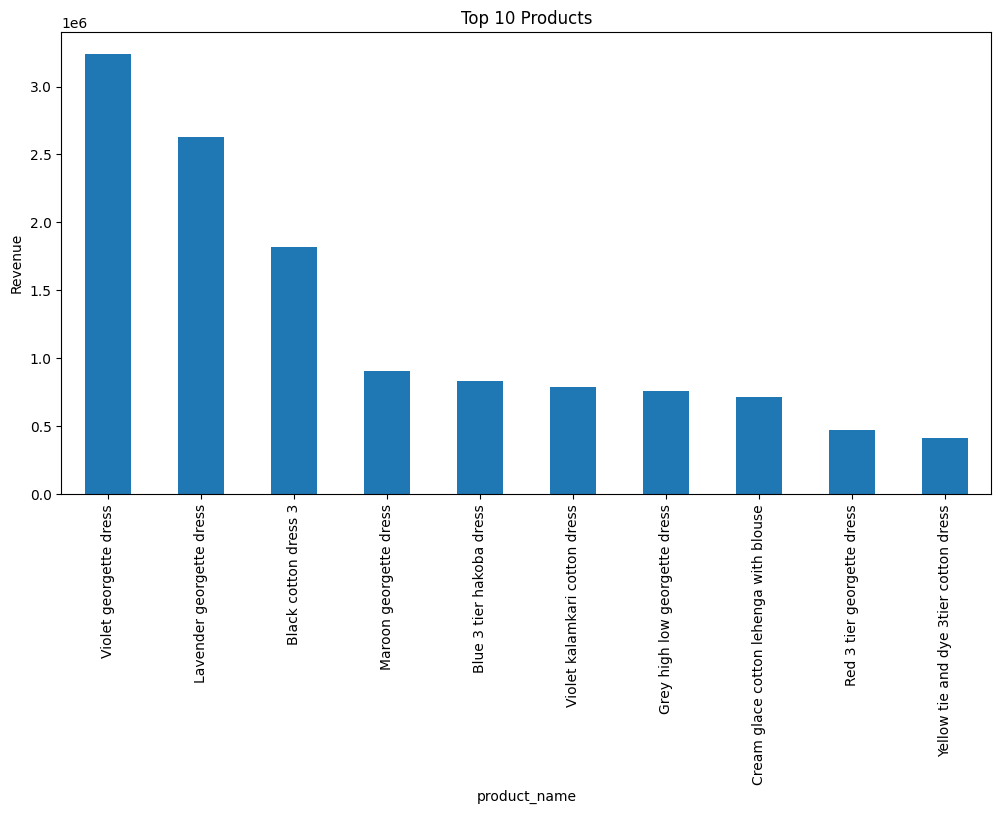

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products")

plt.ylabel("Revenue")

plt.show()

In [16]:
master['date_created'] = pd.to_datetime(master['date_created'])

In [17]:
monthly_sales = (
    master.groupby(
        master['date_created'].dt.to_period('M')
    )['line_total']
    .sum()
)

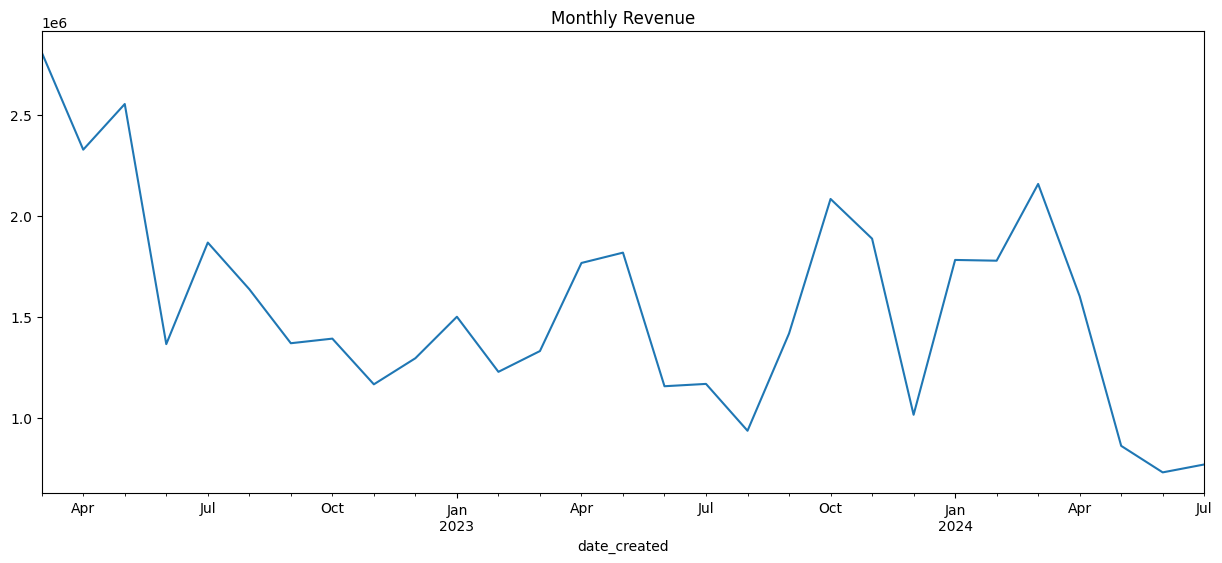

In [18]:
monthly_sales.plot(figsize=(15,6))

plt.title("Monthly Revenue")

plt.show()

In [19]:
# ==============================
# Executive Summary
# ==============================

print("="*60)
print("E-COMMERCE SALES DASHBOARD")
print("="*60)

print(f"Total Revenue           : ₹{master['line_total'].sum():,.2f}")
print(f"Total Orders            : {master['order_id'].nunique():,}")
print(f"Total Customers         : {master['customer_id'].nunique():,}")
print(f"Products Sold           : {master['product_id'].nunique():,}")

avg_order = master.groupby('order_id')['line_total'].sum().mean()
print(f"Average Order Value     : ₹{avg_order:,.2f}")

print("="*60)

E-COMMERCE SALES DASHBOARD
Total Revenue           : ₹44,831,205.20
Total Orders            : 17,444
Total Customers         : 14,640
Products Sold           : 714
Average Order Value     : ₹2,570.01


In [20]:
top_products = (
    master.groupby("product_name")["line_total"]
          .sum()
          .sort_values(ascending=False)
          .head(10)
)

top_products

product_name
Violet georgette dress                    3240446.28
Lavender georgette dress                  2626895.12
Black cotton dress 3                      1820387.03
Maroon georgette dress                     903868.24
Blue 3 tier hakoba dress                   832094.48
Violet kalamkari cotton dress              790341.33
Grey high low georgette dress              756666.76
Cream glace cotton lehenga with blouse     713634.39
Red 3 tier georgette dress                 468131.04
Yellow tie and dye 3tier cotton dress      412025.91
Name: line_total, dtype: float64

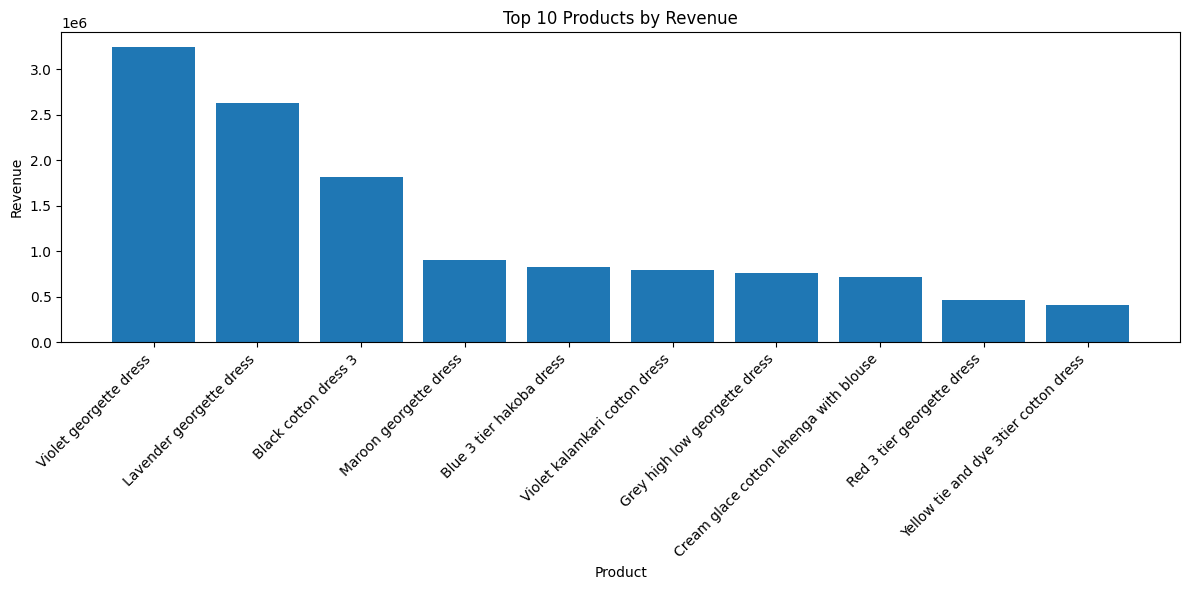

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(top_products.index, top_products.values)

plt.xticks(rotation=45, ha='right')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [23]:
#Insight: The top 10 products contribute a significant portion of total revenue. These products should be prioritized for inventory management and marketing campaigns.

In [24]:
master["date_created"] = pd.to_datetime(master["date_created"])

monthly_sales = (
    master.groupby(master["date_created"].dt.to_period("M"))
          ["line_total"]
          .sum()
)

monthly_sales

date_created
2022-03    2809412.0
2022-04    2327750.0
2022-05    2553795.0
2022-06    1364850.0
2022-07    1867675.0
2022-08    1636755.0
2022-09    1369268.0
2022-10    1392030.0
2022-11    1165750.0
2022-12    1295010.0
2023-01    1500368.0
2023-02    1227616.1
2023-03    1330494.5
2023-04    1766698.8
2023-05    1817828.5
2023-06    1156318.6
2023-07    1167863.5
2023-08     935898.5
2023-09    1417495.7
2023-10    2083610.0
2023-11    1886985.0
2023-12    1015054.0
2024-01    1781648.0
2024-02    1777933.0
2024-03    2157959.0
2024-04    1602013.0
2024-05     861091.0
2024-06     729763.0
2024-07     768922.0
Freq: M, Name: line_total, dtype: float64

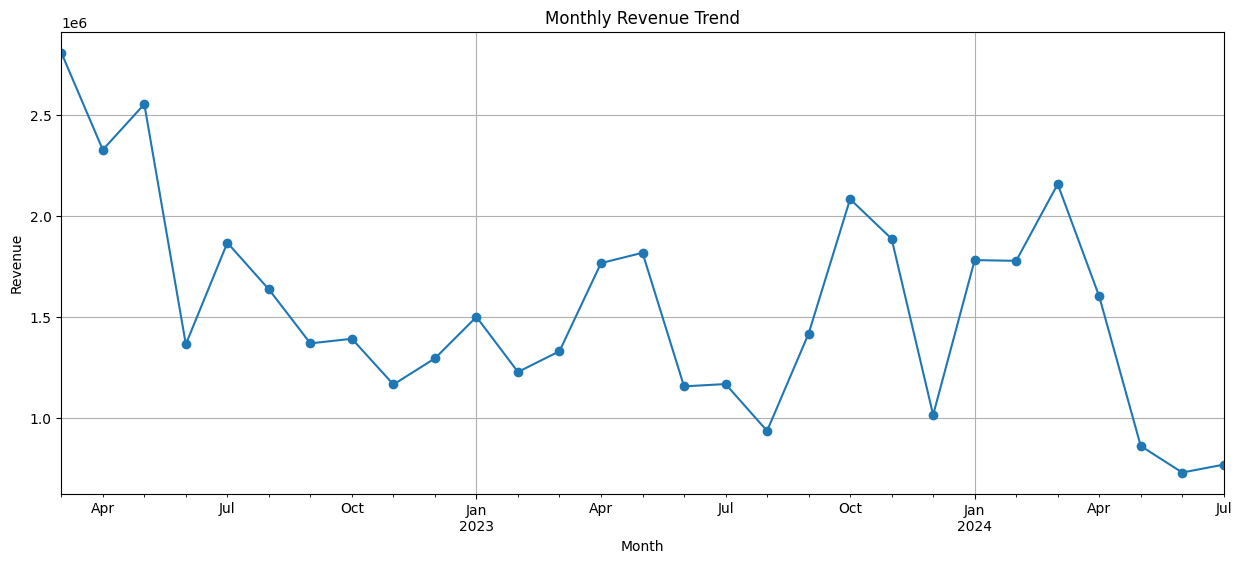

In [26]:
plt.figure(figsize=(15,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [27]:
country_sales = (
    master.groupby("country")["line_total"]
          .sum()
          .sort_values(ascending=False)
)

country_sales

country
IN    42312664.2
US     1545893.0
AU      259225.0
CA      216660.0
MY      146094.0
GB      134959.0
SG       18150.0
FR       15950.0
IT       13800.0
HK       13000.0
DE       10550.0
AE        8400.0
IE        4450.0
KW        3000.0
QA        1600.0
PH        1550.0
LK        1400.0
Name: line_total, dtype: float64

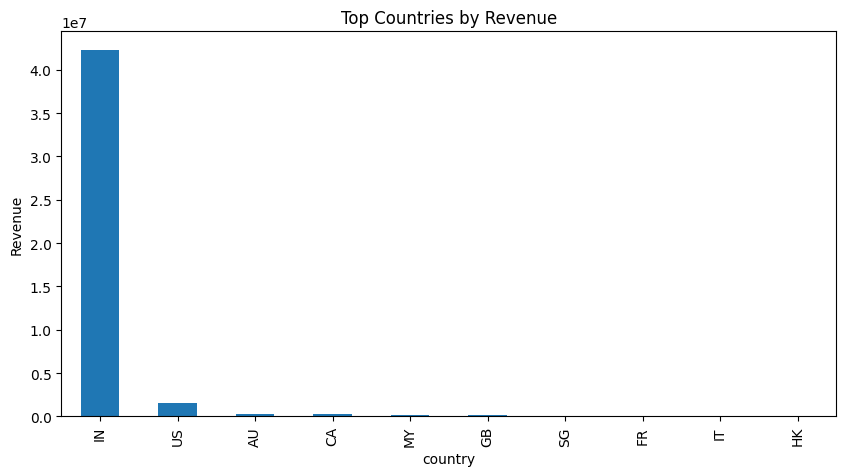

In [28]:
plt.figure(figsize=(10,5))

country_sales.head(10).plot(kind="bar")

plt.title("Top Countries by Revenue")

plt.ylabel("Revenue")

plt.show()

In [29]:
city_sales = (
    master.groupby("city")["line_total"]
          .sum()
          .sort_values(ascending=False)
)

city_sales.head(10)

city
Hyderabad        7524615.3
Chennai          4283081.2
Bangalore        1896377.2
Coimbatore       1069027.3
Bengaluru        1036866.2
Visakhapatnam     743269.6
Guntur            646889.5
Vijayawada        611159.0
Secunderabad      399967.0
Madurai           347957.0
Name: line_total, dtype: float64

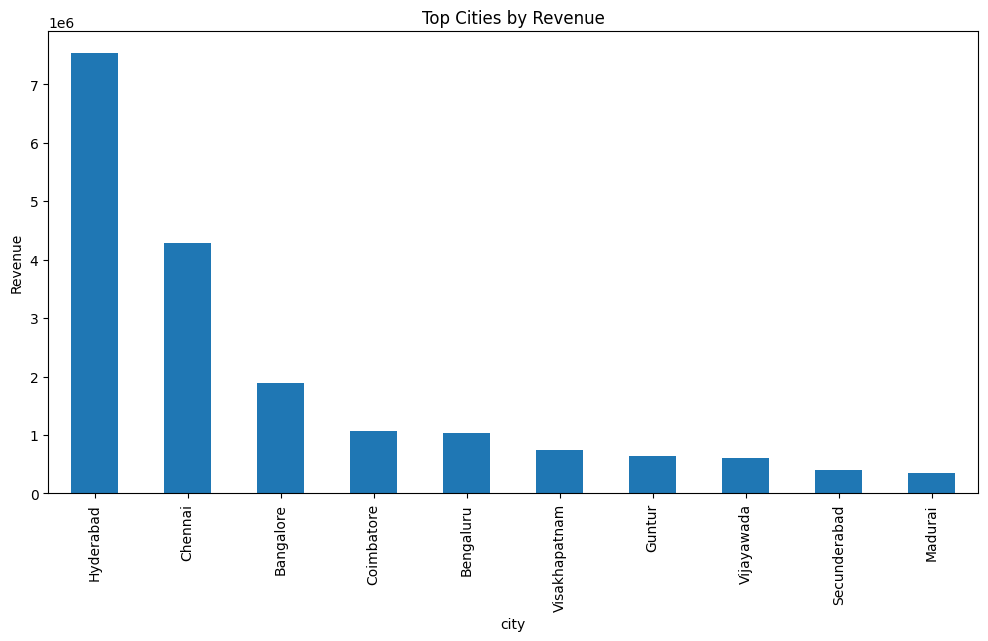

In [30]:
plt.figure(figsize=(12,6))

city_sales.head(10).plot(kind="bar")

plt.title("Top Cities by Revenue")

plt.ylabel("Revenue")

plt.show()

In [31]:
customer_type = (
    master.groupby("returning_customer")
          ["customer_id"]
          .count()
)

customer_type

returning_customer
0.0    22983
1.0     3533
Name: customer_id, dtype: int64

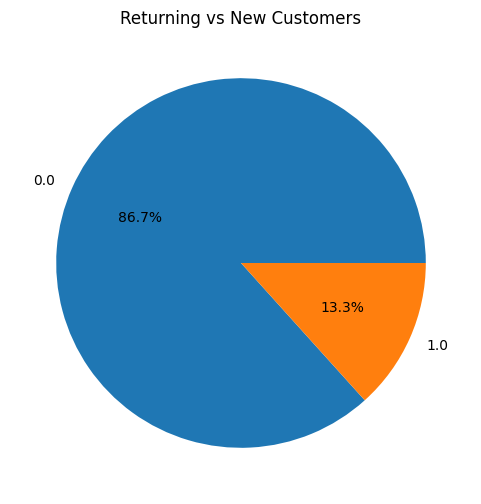

In [32]:
customer_type.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Returning vs New Customers")

plt.show()